# 3.3 Basic — Web Signal Models

Web signal features only (Google Trends).

**Pipeline:** Gold → Model outputs  
**Input:** `Data/3_Gold/basetable_preprocessed.csv`  
**Output:** Model metrics and visualisations

<!-- toc -->
## Contents
- [Setup](#setup)
- [1. Load Data & Compute Target](#1-load-data-compute-target)
- [2. Train/Val/Test Split](#2-trainvaltest-split)
- [3. CV Folds](#3-cv-folds)
- [4. Helper Functions](#4-helper-functions)
- [5. Model 1 — Ridge Regression](#5-model-1-ridge-regression)
- [6. Model 2 — Random Forest Regressor](#6-model-2-random-forest-regressor)
- [7. Model 3 — Support Vector Regression (tuned kernel)](#7-model-3-support-vector-regression-tuned-kernel)
- [8. Model 4 — XGBoost Regressor](#8-model-4-xgboost-regressor)
- [9. Naive Baseline — Always Predict Zero](#9-naive-baseline-always-predict-zero)
- [10. Model Comparison](#10-model-comparison)


## Setup

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "../../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
try:
    from xgboost import XGBRegressor
except ImportError:
    raise ImportError("XGBoost not found. Install with: pip install xgboost")

from Functions.data_splits import (
    get_cv_folds, get_test_split, print_fold_summary, validate_no_leakage,
)
from Functions.evaluation_metrics import (
    directional_accuracy, compute_metrics, cv_evaluate, final_eval, tune_hyperparams,
)
from house_style import *
apply_style()

RANDOM_STATE = 42
TEST_DAYS    = 14
N_SPLITS     = 3
GAP          = 1

DATA_PATH = "../../../Data/3_Gold/basetable_preprocessed.csv"

GT_COLS = [
    "gt_trump", "gt_kamala", "gt_walz", "gt_election_2024",
    "gt_trump_minus_kamala", "gt_trump_share",
    "gt_trump_7d", "gt_kamala_7d",
    "gt_trump_lag1", "gt_trump_share_lag1",
]

POLL_COLS = [
    "poll_trump_avg", "poll_harris_avg", "poll_margin",
    "poll_trump_7d_avg", "poll_harris_7d_avg", "poll_margin_7d_avg",
    "poll_volatility_7d", "poll_margin_lag1", "poll_market_divergence_lag1",
]

WEB_COLS = GT_COLS + POLL_COLS

MODEL_COLORS = {
    "Naive (zero)"    : NEUTRAL,
    "Ridge Regression": PALETTE[0],
    "Random Forest"   : PALETTE[1],
    "SVM"             : PALETTE[4],
    "XGBoost"         : PALETTE[2],
}

print("Imports OK")

Imports OK


## 1. Load Data & Compute Target

We load `basetable_preprocessed.csv` and keep only the 19 web columns (GT + polls).

**Target derivation:**  
`target(t) = polymarket_trump_prob(t) − polymarket_trump_prob_lag1(t) = prob(t) − prob(t−1)`

Using the pre-computed `polymarket_trump_prob_lag1` column (already in the preprocessed file) mirrors the approach in `1_lag.ipynb` and avoids any forward-looking `.diff()` ambiguity at dataset boundaries.

In [2]:
df_raw = pd.read_csv(DATA_PATH, parse_dates=["date"])
df_raw = df_raw.sort_values("date").reset_index(drop=True)

missing = [c for c in WEB_COLS if c not in df_raw.columns]
assert not missing, f"Missing web columns: {missing} — re-run preprocessing.ipynb"
assert "polymarket_trump_prob_lag1" in df_raw.columns, \
    "polymarket_trump_prob_lag1 not found — re-run preprocessing.ipynb"

df = df_raw[["date"] + WEB_COLS].copy()
df["target"] = df_raw["polymarket_trump_prob"] - df_raw["polymarket_trump_prob_lag1"]
df = df.dropna().reset_index(drop=True)

print(f"Rows          : {len(df)}")
print(f"Date range    : {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"Features ({len(WEB_COLS)}): {len(GT_COLS)} Google Trends + {len(POLL_COLS)} polls")
print(f"\nTarget (daily delta prob) stats:")
print(df["target"].describe().round(5))

Rows          : 123
Date range    : 2024-07-05 -> 2024-11-04
Features (19): 10 Google Trends + 9 polls

Target (daily delta prob) stats:
count    123.00000
mean      -0.00020
std        0.01782
min       -0.06000
25%       -0.01000
50%        0.00000
75%        0.00900
max        0.08000
Name: target, dtype: float64


## 2. Train/Val/Test Split

`get_test_split` carves off the **last 14 rows** as a completely held-out test set. These dates are never seen during training or model selection — they are used only once for the final reported numbers.

In [3]:
tv_idx, test_idx = get_test_split(df, test_days=TEST_DAYS)

df_tv   = df.iloc[tv_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

X_tv   = df_tv[WEB_COLS].values
y_tv   = df_tv["target"].values
X_test = df_test[WEB_COLS].values
y_test = df_test["target"].values

print(f"Train/val : {len(df_tv):>4} rows  ({df_tv['date'].min().date()} -> {df_tv['date'].max().date()})")
print(f"Test      : {len(df_test):>4} rows  ({df_test['date'].min().date()} -> {df_test['date'].max().date()})")

Train/val :  109 rows  (2024-07-05 -> 2024-10-21)
Test      :   14 rows  (2024-10-22 -> 2024-11-04)


## 3. CV Folds

**3 expanding-window folds** on the TV set with a 1-day gap. `validate_no_leakage` asserts: no index overlap, all training dates strictly before validation dates, and the calendar gap ≥ 1 day.

In [4]:
folds = get_cv_folds(df_tv, n_splits=N_SPLITS, gap=GAP, test_days=None)
print_fold_summary(df_tv, folds)

print("\nLeakage validation:")
for i, (tr, va) in enumerate(folds, 1):
    validate_no_leakage(tr, va, df_tv, gap=GAP)
    print(f"  Fold {i}: OK")

Fold   Train start     Train end   #Train     Val start       Val end    #Val
-----------------------------------------------------------------------------
   1    2024-07-05    2024-07-31       27    2024-08-02    2024-08-28      27
   2    2024-07-05    2024-08-27       54    2024-08-29    2024-09-24      27
   3    2024-07-05    2024-09-23       81    2024-09-25    2024-10-21      27

Leakage validation:
  Fold 1: OK
  Fold 2: OK
  Fold 3: OK


## 4. Helper Functions

All helpers are imported from `Functions.evaluation_metrics`:
- **`directional_accuracy`**, **`compute_metrics`**, **`cv_evaluate`**, **`final_eval`**, **`tune_hyperparams`**

Scalers in `cv_evaluate` and `final_eval` are fitted exclusively on training data — validation/test sets are only transformed, never fitted on.

## 5. Model 1 — Ridge Regression

Ridge adds an L2 penalty (λ‖β‖²) to the OLS objective, shrinking coefficients toward zero. With 19 features and a minimum training fold of only 27 rows (n/p ≈ 1.4), OLS is severely underdetermined and overfits badly (CV R² ≈ −7.9 in fold 1). Ridge's regularisation stabilises the solution.

**Tuned:** `alpha` (regularisation strength) — larger α → stronger shrinkage.  
**Scaling applied** — Ridge is sensitive to feature scale; StandardScaler is fitted on train only.

In [5]:
def make_ridge(alpha):
    return Ridge(alpha=alpha)

ridge_param_grid = {
    "alpha": [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
}

print("=== Ridge Regression — Hyperparameter Tuning ===")
ridge_best, ridge_tune_df = tune_hyperparams(
    make_ridge, ridge_param_grid, folds, X_tv, y_tv, scale=True
)
print(f"  Best params : {ridge_best}")
print(f"\n  All configurations (sorted by CV MAE):")
print(ridge_tune_df.to_string(index=False))

ridge_factory = lambda: make_ridge(**ridge_best)
print("\n=== Ridge Regression — CV (best params) ===")
ridge_cv = cv_evaluate(ridge_factory, folds, X_tv, y_tv, scale=True)
ridge_cv.round(4)

=== Ridge Regression — Hyperparameter Tuning ===
  Best params : {'alpha': 1000.0}

  All configurations (sorted by CV MAE):
  alpha   cv_mae  cv_mae_std
1000.00 0.010250    0.001851
 100.00 0.010293    0.001940
  10.00 0.011315    0.002477
   1.00 0.012144    0.002580
   0.10 0.012936    0.003055
   0.01 0.017002    0.008431

=== Ridge Regression — CV (best params) ===
  Fold 1: MAE=0.0116  RMSE=0.0151  DA=0.556  R2=-0.0068
  Fold 2: MAE=0.0076  RMSE=0.0099  DA=0.481  R2=-0.0061
  Fold 3: MAE=0.0115  RMSE=0.0160  DA=0.333  R2=-0.2607
  -- Mean --  MAE=0.0102  RMSE=0.0137  DA=0.457  R2=-0.0912


,MAE,RMSE,Dir. Accuracy,R2
1,0.0116,0.0151,0.5556,-0.0068
2,0.0076,0.0099,0.4815,-0.0061
3,0.0115,0.0160,0.3333,-0.2607
Mean,0.0102,0.0137,0.4568,-0.0912
Std,0.0023,0.0033,0.1132,0.1468


Ridge Regression — Test set  (alpha=1000.0):
  MAE: 0.0161
  RMSE: 0.0206
  Dir. Accuracy: 0.4286
  R2: -0.0433


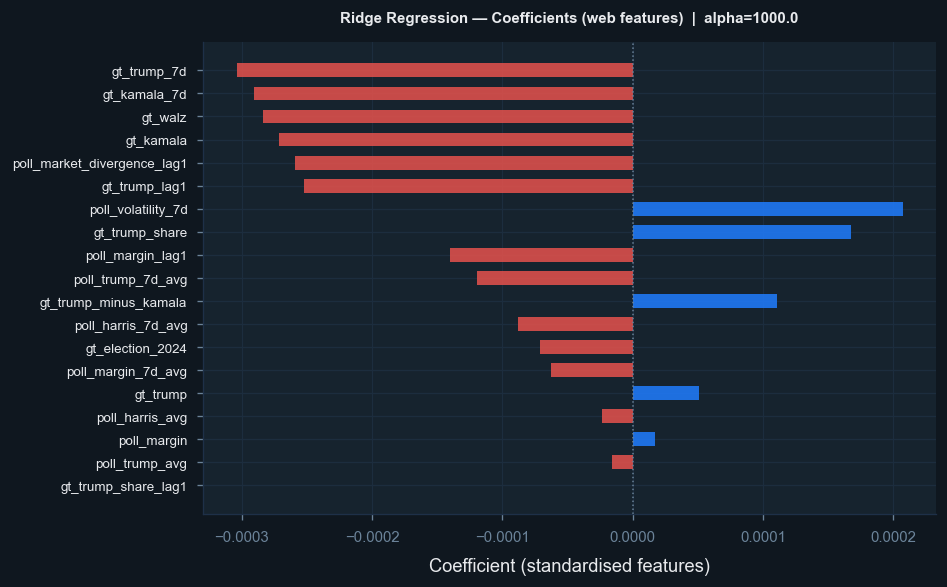

In [6]:
ridge_model, ridge_pred, ridge_test = final_eval(
    ridge_factory, X_tv, y_tv, X_test, y_test, scale=True
)
print(f"Ridge Regression — Test set  (alpha={ridge_best['alpha']}):")
for k, v in ridge_test.items():
    print(f"  {k}: {v:.4f}")

sc_ridge = StandardScaler().fit(X_tv)
coefs    = pd.Series(
    Ridge(alpha=ridge_best["alpha"]).fit(sc_ridge.transform(X_tv), y_tv).coef_,
    index=WEB_COLS,
).sort_values(key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)
colors_coef = [MODEL_COLORS["Ridge Regression"] if v >= 0 else REPUBLICAN for v in coefs.values]
ax.barh(coefs.index, coefs.values, color=colors_coef, alpha=0.85, height=0.6)
ax.axvline(0, color=TEXT_MUTED, linewidth=0.9, linestyle=":")
ax.set_xlabel("Coefficient (standardised features)", color=TEXT_PRIMARY)
ax.set_title(f"Ridge Regression — Coefficients (web features)  |  alpha={ridge_best['alpha']}",
             color=TEXT_PRIMARY, fontweight="bold", fontsize=9)
for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
ax.tick_params(colors=TEXT_MUTED)
ax.set_yticklabels(coefs.index, color=TEXT_PRIMARY, fontsize=8)
ax.grid(axis="x", color=GRID_COLOR, linewidth=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 6. Model 2 — Random Forest Regressor

Random Forest averages many decision trees to reduce variance. With 15 features, the random feature subset per split (`sqrt(15) ≈ 4`) still provides meaningful diversity.

**Fixed:** `n_estimators=200`, `random_state=42`.  
**Tuned:** `max_depth`, `min_samples_leaf`.  
**No scaling required.**

In [7]:
def make_rf(max_depth, min_samples_leaf):
    return RandomForestRegressor(
        n_estimators=200,
        max_depth=int(max_depth),
        min_samples_leaf=int(min_samples_leaf),
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

rf_param_grid = {
    "max_depth"       : [2, 3, 4, 5],
    "min_samples_leaf": [1, 2, 3, 5],
}

print("=== Random Forest — Hyperparameter Tuning ===")
rf_best, rf_tune_df = tune_hyperparams(
    make_rf, rf_param_grid, folds, X_tv, y_tv, scale=False
)
print(f"  Best params : {rf_best}")
print(f"\n  Top-5 configurations (sorted by CV MAE):")
print(rf_tune_df.head(5).to_string(index=False))

rf_factory = lambda: make_rf(**rf_best)
print("\n=== Random Forest — CV (best params) ===")
rf_cv = cv_evaluate(rf_factory, folds, X_tv, y_tv, scale=False)
rf_cv.round(4)

=== Random Forest — Hyperparameter Tuning ===
  Best params : {'max_depth': 2, 'min_samples_leaf': 5}

  Top-5 configurations (sorted by CV MAE):
 max_depth  min_samples_leaf   cv_mae  cv_mae_std
         2                 5 0.011251    0.001942
         3                 5 0.011413    0.002047
         2                 3 0.011516    0.002391
         4                 5 0.011589    0.002133
         5                 5 0.011616    0.002150

=== Random Forest — CV (best params) ===
  Fold 1: MAE=0.0130  RMSE=0.0163  DA=0.444  R2=-0.1712
  Fold 2: MAE=0.0085  RMSE=0.0109  DA=0.444  R2=-0.2274
  Fold 3: MAE=0.0122  RMSE=0.0167  DA=0.370  R2=-0.3651
  -- Mean --  MAE=0.0113  RMSE=0.0146  DA=0.420  R2=-0.2546


,MAE,RMSE,Dir. Accuracy,R2
1,0.0130,0.0163,0.4444,-0.1712
2,0.0085,0.0109,0.4444,-0.2274
3,0.0122,0.0167,0.3704,-0.3651
Mean,0.0113,0.0146,0.4198,-0.2546
Std,0.0024,0.0032,0.0428,0.0998


Random Forest — Test set:
  MAE: 0.0160
  RMSE: 0.0202
  Dir. Accuracy: 0.5000
  R2: 0.0005


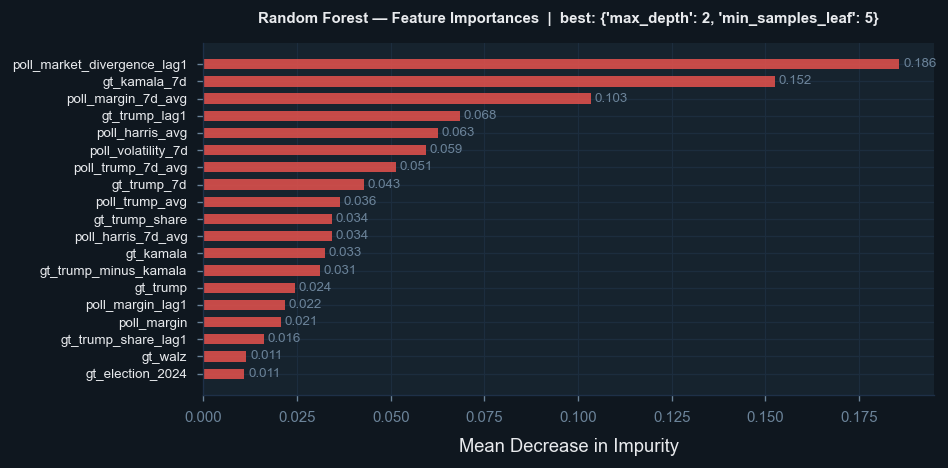

In [8]:
rf_model, rf_pred, rf_test = final_eval(
    rf_factory, X_tv, y_tv, X_test, y_test, scale=False
)
print("Random Forest — Test set:")
for k, v in rf_test.items():
    print(f"  {k}: {v:.4f}")

fi = pd.Series(rf_model.feature_importances_, index=WEB_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)
bars = ax.barh(fi.index, fi.values, color=MODEL_COLORS["Random Forest"], alpha=0.85, height=0.6)
for bar, v in zip(bars, fi.values):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f"{v:.3f}", va="center", ha="left", fontsize=8, color=TEXT_MUTED)
ax.set_xlabel("Mean Decrease in Impurity", color=TEXT_PRIMARY)
ax.set_title(f"Random Forest — Feature Importances  |  best: {rf_best}",
             color=TEXT_PRIMARY, fontweight="bold", fontsize=9)
for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
ax.tick_params(colors=TEXT_MUTED)
ax.set_yticklabels(fi.index, color=TEXT_PRIMARY, fontsize=8)
ax.grid(axis="x", color=GRID_COLOR, linewidth=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 7. Model 3 — Support Vector Regression (tuned kernel)

SVR maximises a geometric margin; the kernel implicitly maps features into a higher-dimensional space enabling non-linear regression.

**Fixed:** `gamma='scale'`.  
**Tuned:** `kernel` (linear / rbf / poly / sigmoid), `C`, `epsilon`.  
**Scaling required** — distances in feature space are distorted by unscaled features.

In [9]:
def make_svr(kernel, C, epsilon):
    return SVR(kernel=kernel, C=C, epsilon=epsilon, gamma="scale")

svr_param_grid = {
    "kernel" : ["linear", "rbf", "poly", "sigmoid"],
    "C"      : [0.1, 1.0, 10.0, 100.0],
    "epsilon": [0.0001, 0.001, 0.01, 0.05],
}

print("=== SVM — Hyperparameter Tuning ===")
svr_best, svr_tune_df = tune_hyperparams(
    make_svr, svr_param_grid, folds, X_tv, y_tv, scale=True
)
print(f"  Best params : {svr_best}")
print(f"\n  Top-10 configurations (sorted by CV MAE):")
print(svr_tune_df.head(10).to_string(index=False))

svr_factory = lambda: make_svr(**svr_best)
print("\n=== SVM — CV (best params) ===")
svm_cv = cv_evaluate(svr_factory, folds, X_tv, y_tv, scale=True)
svm_cv.round(4)

=== SVM — Hyperparameter Tuning ===
  Best params : {'kernel': 'linear', 'C': 0.1, 'epsilon': 0.01}

  Top-10 configurations (sorted by CV MAE):
 kernel     C  epsilon   cv_mae  cv_mae_std
 linear   0.1   0.0100 0.011841    0.002028
 linear 100.0   0.0100 0.013278    0.003440
 linear  10.0   0.0100 0.013312    0.003405
    rbf   0.1   0.0100 0.013546    0.002177
    rbf   0.1   0.0001 0.013559    0.003299
    rbf   0.1   0.0010 0.013593    0.003390
 linear   1.0   0.0100 0.013755    0.003940
sigmoid   0.1   0.0100 0.015768    0.002264
    rbf   1.0   0.0100 0.016200    0.003488
 linear   0.1   0.0010 0.016871    0.009016

=== SVM — CV (best params) ===
  Fold 1: MAE=0.0135  RMSE=0.0170  DA=0.407  R2=-0.2814
  Fold 2: MAE=0.0090  RMSE=0.0105  DA=0.519  R2=-0.1276
  Fold 3: MAE=0.0130  RMSE=0.0177  DA=0.407  R2=-0.5396
  -- Mean --  MAE=0.0118  RMSE=0.0151  DA=0.444  R2=-0.3162


,MAE,RMSE,Dir. Accuracy,R2
1,0.0135,0.0170,0.4074,-0.2814
2,0.0090,0.0105,0.5185,-0.1276
3,0.0130,0.0177,0.4074,-0.5396
Mean,0.0118,0.0151,0.4444,-0.3162
Std,0.0025,0.0040,0.0642,0.2082


In [10]:
svm_model, svm_pred, svm_test = final_eval(
    svr_factory, X_tv, y_tv, X_test, y_test, scale=True
)
print(f"SVM — Test set  (kernel={svr_best['kernel']}, C={svr_best['C']}, ε={svr_best['epsilon']}):")
for k, v in svm_test.items():
    print(f"  {k}: {v:.4f}")

SVM — Test set  (kernel=linear, C=0.1, ε=0.01):
  MAE: 0.0160
  RMSE: 0.0201
  Dir. Accuracy: 0.4286
  R2: 0.0078


## 8. Model 4 — XGBoost Regressor

XGBoost sequentially builds shallow trees on the pseudo-residuals of the current ensemble. With only 15 features, `colsample_bytree=0.8` uses 12 features per tree — sufficient diversity without discarding signal.

**Fixed:** `subsample=0.8`, `colsample_bytree=0.8`, `objective='reg:squarederror'`, `random_state=42`.  
**Tuned:** `max_depth`, `learning_rate`, `n_estimators`.  
**No scaling required.**

In [11]:
def make_xgb(max_depth, learning_rate, n_estimators):
    return XGBRegressor(
        max_depth=int(max_depth),
        learning_rate=learning_rate,
        n_estimators=int(n_estimators),
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        verbosity=0,
    )

xgb_param_grid = {
    "max_depth"    : [2, 3, 4],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators" : [100, 200],
}

print("=== XGBoost — Hyperparameter Tuning ===")
xgb_best, xgb_tune_df = tune_hyperparams(
    make_xgb, xgb_param_grid, folds, X_tv, y_tv, scale=False
)
print(f"  Best params : {xgb_best}")
print(f"\n  Top-5 configurations (sorted by CV MAE):")
print(xgb_tune_df.head(5).to_string(index=False))

xgb_factory = lambda: make_xgb(**xgb_best)
print("\n=== XGBoost — CV (best params) ===")
xgb_cv = cv_evaluate(xgb_factory, folds, X_tv, y_tv, scale=False)
xgb_cv.round(4)

=== XGBoost — Hyperparameter Tuning ===
  Best params : {'max_depth': 2, 'learning_rate': 0.01, 'n_estimators': 100}

  Top-5 configurations (sorted by CV MAE):
 max_depth  learning_rate  n_estimators   cv_mae  cv_mae_std
         2           0.01           100 0.010644    0.001852
         3           0.01           100 0.010672    0.002029
         4           0.01           100 0.010683    0.002170
         2           0.01           200 0.011094    0.001944
         3           0.01           200 0.011360    0.002405

=== XGBoost — CV (best params) ===
  Fold 1: MAE=0.0119  RMSE=0.0148  DA=0.481  R2=0.0334
  Fold 2: MAE=0.0080  RMSE=0.0101  DA=0.444  R2=-0.0415
  Fold 3: MAE=0.0120  RMSE=0.0164  DA=0.370  R2=-0.3237
  -- Mean --  MAE=0.0106  RMSE=0.0138  DA=0.432  R2=-0.1106


,MAE,RMSE,Dir. Accuracy,R2
1,0.0119,0.0148,0.4815,0.0334
2,0.0080,0.0101,0.4444,-0.0415
3,0.0120,0.0164,0.3704,-0.3237
Mean,0.0106,0.0138,0.4321,-0.1106
Std,0.0023,0.0033,0.0566,0.1883


XGBoost — Test set:
  MAE: 0.0156
  RMSE: 0.0196
  Dir. Accuracy: 0.5714
  R2: 0.0569


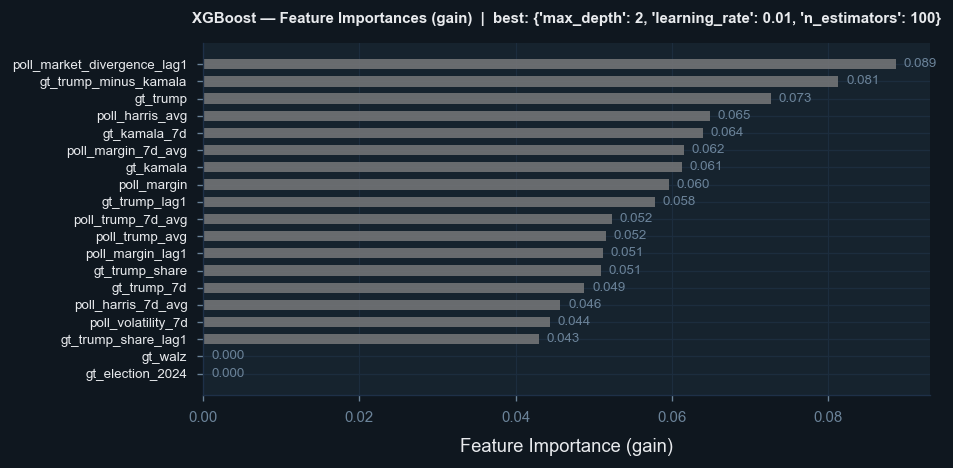

In [12]:
xgb_model, xgb_pred, xgb_test = final_eval(
    xgb_factory, X_tv, y_tv, X_test, y_test, scale=False
)
print("XGBoost — Test set:")
for k, v in xgb_test.items():
    print(f"  {k}: {v:.4f}")

fi_xgb = pd.Series(xgb_model.feature_importances_, index=WEB_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)
bars = ax.barh(fi_xgb.index, fi_xgb.values, color=MODEL_COLORS["XGBoost"], alpha=0.85, height=0.6)
for bar, v in zip(bars, fi_xgb.values):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f"{v:.3f}", va="center", ha="left", fontsize=8, color=TEXT_MUTED)
ax.set_xlabel("Feature Importance (gain)", color=TEXT_PRIMARY)
ax.set_title(f"XGBoost — Feature Importances (gain)  |  best: {xgb_best}",
             color=TEXT_PRIMARY, fontweight="bold", fontsize=9)
for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
ax.tick_params(colors=TEXT_MUTED)
ax.set_yticklabels(fi_xgb.index, color=TEXT_PRIMARY, fontsize=8)
ax.grid(axis="x", color=GRID_COLOR, linewidth=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 9. Naive Baseline — Always Predict Zero

The naive model always predicts `Δ prob = 0`. This is the random-walk lower bound: R² ≈ 0 for the zero predictor when the mean daily change is near zero. Any model with R² < 0 is worse than predicting no movement.

In [13]:
print("=== Naive (zero) — CV ===")
naive_records = []
for i, (train_idx, val_idx) in enumerate(folds, 1):
    y_val  = y_tv[val_idx]
    y_zero = np.zeros_like(y_val)
    m = {"Fold": i, **compute_metrics(y_val, y_zero)}
    naive_records.append(m)
    print(f"  Fold {i}: MAE={m['MAE']:.4f}  RMSE={m['RMSE']:.4f}  "
          f"DA={m['Dir. Accuracy']:.3f}  R2={m['R2']:.4f}")

naive_agg  = pd.DataFrame(naive_records).set_index("Fold")
naive_mean = naive_agg.mean().rename("Mean")
naive_std  = naive_agg.std().rename("Std")
naive_cv   = pd.concat([naive_agg, naive_mean.to_frame().T, naive_std.to_frame().T])
print(f"  -- Mean --  MAE={naive_mean['MAE']:.4f}  RMSE={naive_mean['RMSE']:.4f}  "
      f"DA={naive_mean['Dir. Accuracy']:.3f}  R2={naive_mean['R2']:.4f}")

naive_pred = np.zeros(len(y_test))
naive_test = compute_metrics(y_test, naive_pred)
print("\nNaive (zero) — Test set:")
for k, v in naive_test.items():
    print(f"  {k}: {v:.4f}")

naive_cv.round(4)

=== Naive (zero) — CV ===
  Fold 1: MAE=0.0116  RMSE=0.0151  DA=0.000  R2=-0.0044
  Fold 2: MAE=0.0076  RMSE=0.0099  DA=0.037  R2=-0.0013
  Fold 3: MAE=0.0111  RMSE=0.0155  DA=0.000  R2=-0.1700
  -- Mean --  MAE=0.0101  RMSE=0.0135  DA=0.012  R2=-0.0586

Naive (zero) — Test set:
  MAE: 0.0162
  RMSE: 0.0208
  Dir. Accuracy: 0.0000
  R2: -0.0570


,MAE,RMSE,Dir. Accuracy,R2
1,0.0116,0.0151,0.0000,-0.0044
2,0.0076,0.0099,0.0370,-0.0013
3,0.0111,0.0155,0.0000,-0.1700
Mean,0.0101,0.0135,0.0123,-0.0586
Std,0.0022,0.0031,0.0214,0.0965


## 10. Model Comparison

CV performance (mean over 3 folds) and test-set performance for all five models. The naive (zero) baseline sets the floor.

In [14]:
cv_summary = pd.DataFrame({
    "Naive (zero)"    : naive_cv.loc["Mean"],
    "Ridge Regression": ridge_cv.loc["Mean"],
    "Random Forest"   : rf_cv.loc["Mean"],
    "SVM"             : svm_cv.loc["Mean"],
    "XGBoost"         : xgb_cv.loc["Mean"],
}).T.round(4)

best_params_col = {
    "Naive (zero)"    : "— (always 0)",
    "Ridge Regression": f"alpha={ridge_best['alpha']}",
    "Random Forest"   : f"d={rf_best['max_depth']}, leaf={rf_best['min_samples_leaf']}",
    "SVM"             : f"k={svr_best['kernel']}, C={svr_best['C']}, ε={svr_best['epsilon']}",
    "XGBoost"         : f"d={xgb_best['max_depth']}, lr={xgb_best['learning_rate']}, n={int(xgb_best['n_estimators'])}",
}
cv_summary.insert(0, "Best params", pd.Series(best_params_col))

print("CV performance (mean across 3 walk-forward folds):")
display(cv_summary)

CV performance (mean across 3 walk-forward folds):


,Best params,MAE,RMSE,Dir. Accuracy,R2
Naive (zero),— (always 0),0.0101,0.0135,0.0123,-0.0586
Ridge Regression,alpha=1000.0,0.0102,0.0137,0.4568,-0.0912
Random Forest,"d=2, leaf=5",0.0113,0.0146,0.4198,-0.2546
SVM,"k=linear, C=0.1, ε=0.01",0.0118,0.0151,0.4444,-0.3162
XGBoost,"d=2, lr=0.01, n=100",0.0106,0.0138,0.4321,-0.1106


In [15]:
test_summary = pd.DataFrame({
    "Naive (zero)"    : naive_test,
    "Ridge Regression": ridge_test,
    "Random Forest"   : rf_test,
    "SVM"             : svm_test,
    "XGBoost"         : xgb_test,
}).T.round(4)

print("Test set performance:")
display(test_summary)

Test set performance:


,MAE,RMSE,Dir. Accuracy,R2
Naive (zero),0.0162,0.0208,0.0000,-0.0570
Ridge Regression,0.0161,0.0206,0.4286,-0.0433
Random Forest,0.0160,0.0202,0.5000,0.0005
SVM,0.0160,0.0201,0.4286,0.0078
XGBoost,0.0156,0.0196,0.5714,0.0569


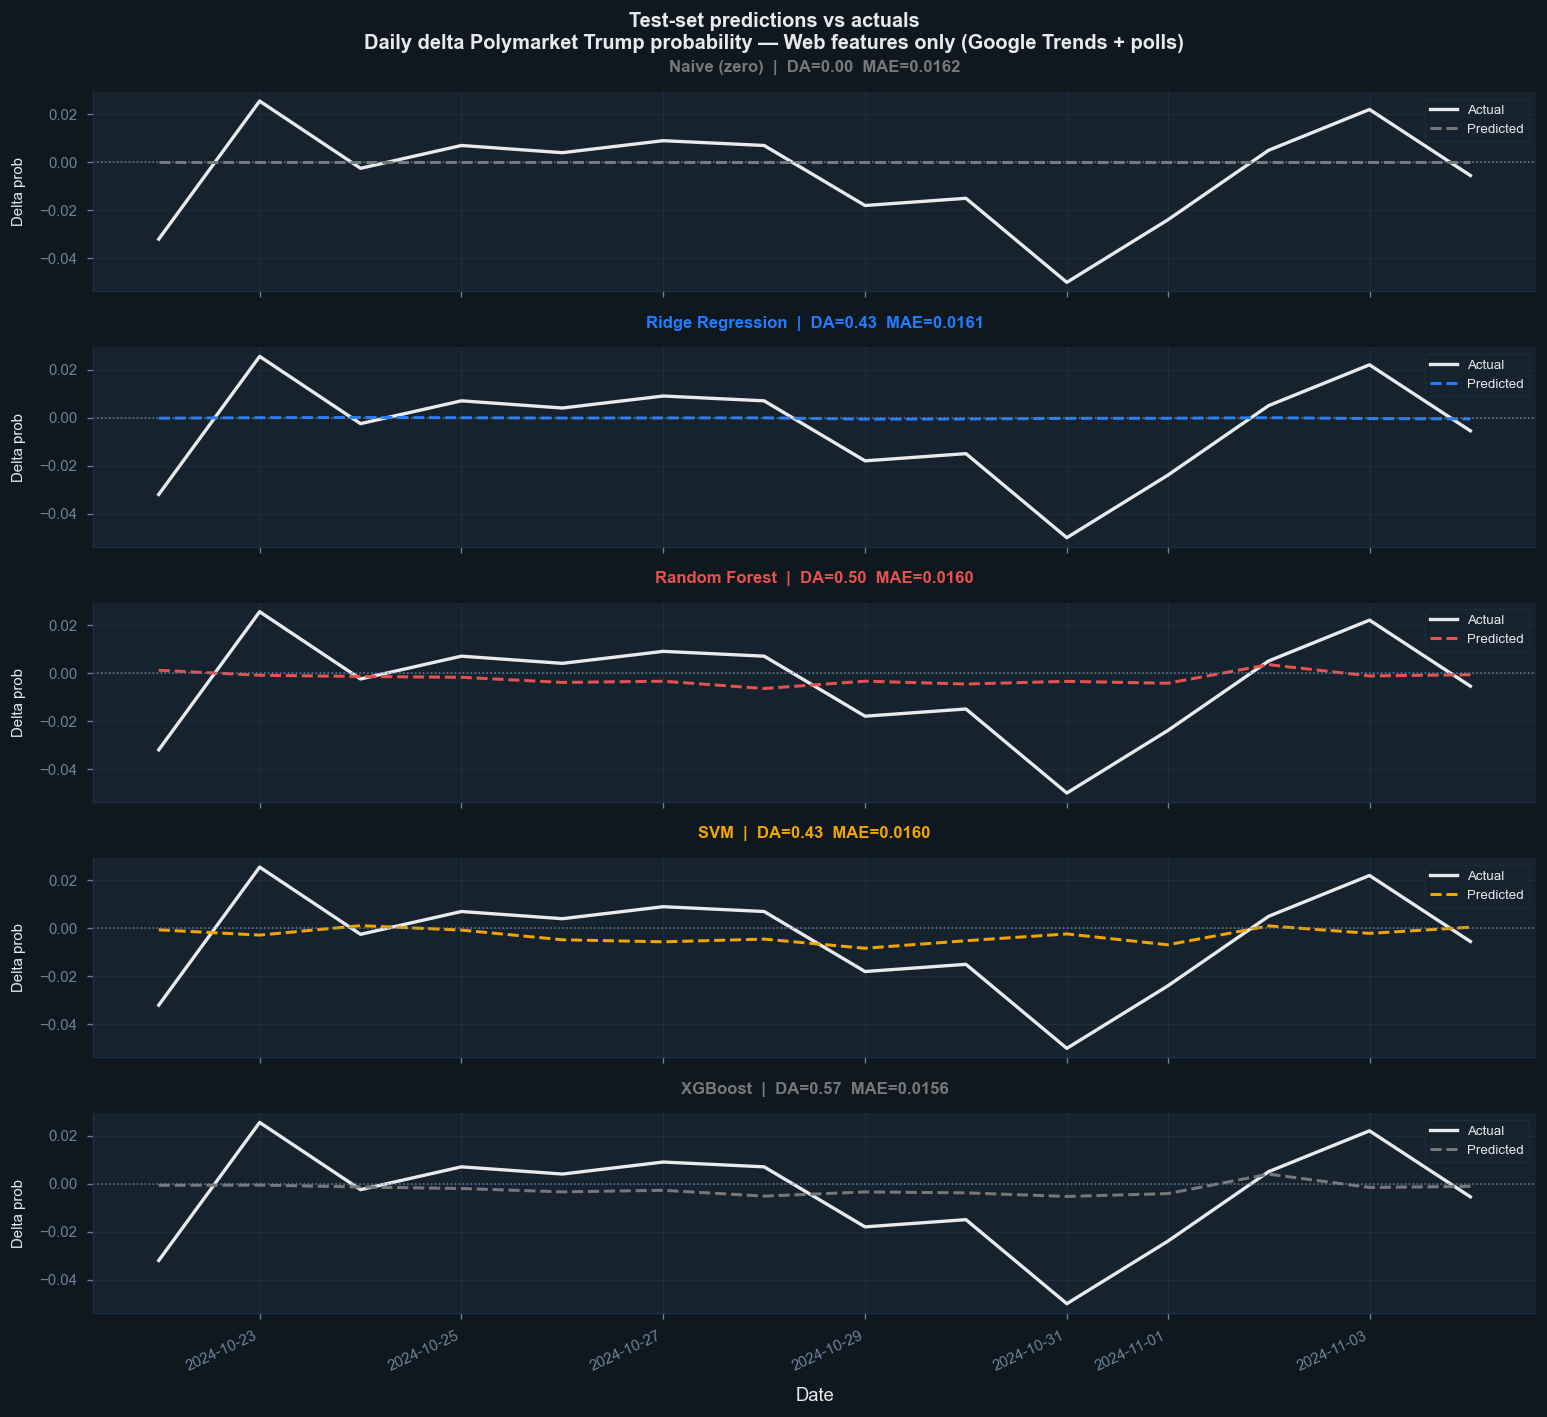

In [16]:
test_dates = df_test["date"].values
preds_list = [
    ("Naive (zero)",      naive_pred),
    ("Ridge Regression",  ridge_pred),
    ("Random Forest",     rf_pred),
    ("SVM",               svm_pred),
    ("XGBoost",           xgb_pred),
]

fig, axes = plt.subplots(5, 1, figsize=(13, 12), sharex=True)
fig.patch.set_facecolor(BG_DARK)

for ax, (label, pred) in zip(axes, preds_list):
    ax.set_facecolor(BG_PANEL)
    ax.plot(test_dates, y_test, label="Actual",    color=TEXT_PRIMARY, linewidth=2)
    ax.plot(test_dates, pred,   label="Predicted", color=MODEL_COLORS[label],
            linewidth=1.8, linestyle="--")
    ax.axhline(0, color=TEXT_MUTED, linewidth=0.9, linestyle=":")
    da  = directional_accuracy(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    ax.set_title(f"{label}  |  DA={da:.2f}  MAE={mae:.4f}",
                 color=MODEL_COLORS[label], fontweight="bold", fontsize=10)
    ax.set_ylabel("Delta prob", color=TEXT_PRIMARY, fontsize=9)
    ax.legend(loc="upper right", facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
              labelcolor=TEXT_PRIMARY, fontsize=8)
    for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
    ax.tick_params(colors=TEXT_MUTED)
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.7)
    ax.set_axisbelow(True)

axes[-1].set_xlabel("Date", color=TEXT_PRIMARY)
plt.xticks(rotation=25, ha="right")
fig.suptitle("Test-set predictions vs actuals\nDaily delta Polymarket Trump probability — Web features only (Google Trends + polls)",
             color=TEXT_PRIMARY, fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

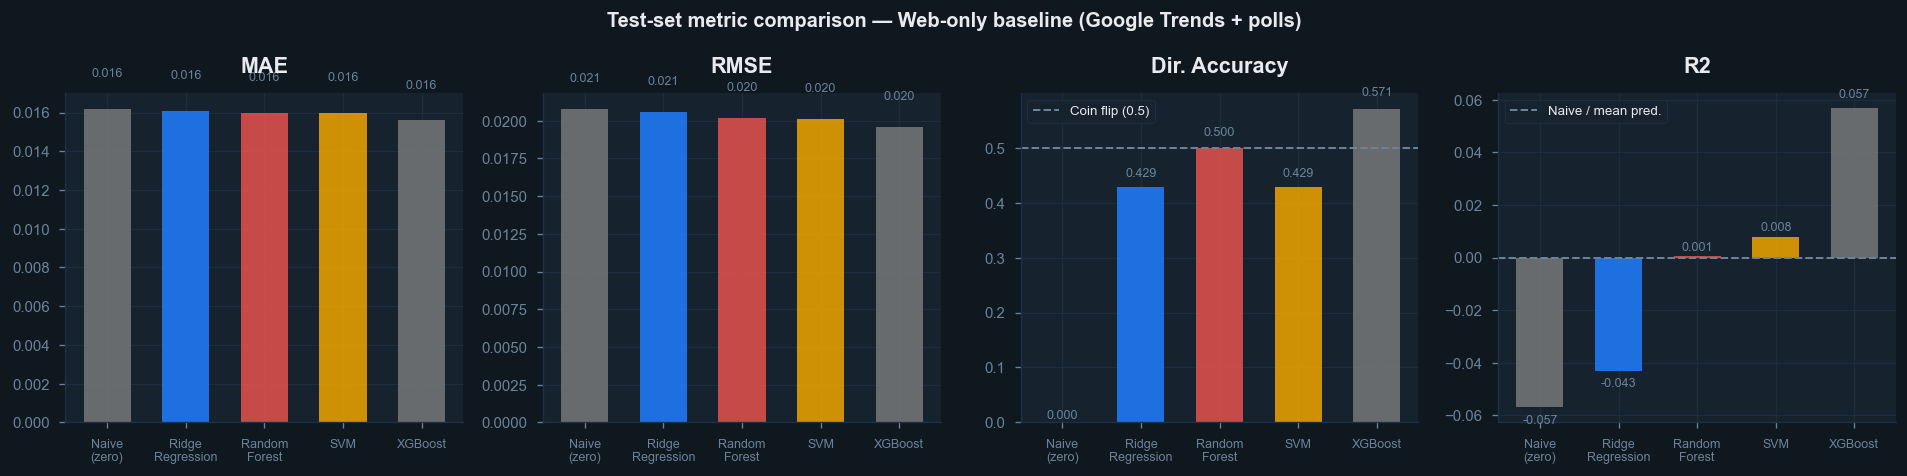

In [17]:
metrics_plot = ["MAE", "RMSE", "Dir. Accuracy", "R2"]
model_names  = list(MODEL_COLORS.keys())
colors_list  = list(MODEL_COLORS.values())

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.patch.set_facecolor(BG_DARK)

for ax, metric in zip(axes, metrics_plot):
    ax.set_facecolor(BG_PANEL)
    vals = [test_summary.loc[m, metric] for m in model_names]
    bars = ax.bar(range(len(model_names)), vals, color=colors_list, alpha=0.85, width=0.6)

    if metric == "Dir. Accuracy":
        ax.axhline(0.5, color=TEXT_MUTED, linestyle="--", linewidth=1.2, label="Coin flip (0.5)")
    if metric == "R2":
        ax.axhline(0, color=TEXT_MUTED, linestyle="--", linewidth=1.2, label="Naive / mean pred.")

    for bar, val in zip(bars, vals):
        offset = abs(val) * 0.03 + 0.001
        va     = "bottom" if val >= 0 else "top"
        y_pos  = bar.get_height() + offset if val >= 0 else bar.get_height() - offset
        ax.text(bar.get_x() + bar.get_width()/2, y_pos,
                f"{val:.3f}", ha="center", va=va, fontsize=7.5, color=TEXT_MUTED)

    ax.set_title(metric, color=TEXT_PRIMARY, fontweight="bold")
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels([m.replace(" ", "\n") for m in model_names],
                       fontsize=7.5, color=TEXT_MUTED)
    for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
    ax.tick_params(colors=TEXT_MUTED)
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.7)
    ax.set_axisbelow(True)
    if metric in ("Dir. Accuracy", "R2"):
        ax.legend(facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY, fontsize=8)

fig.suptitle("Test-set metric comparison — Web-only baseline (Google Trends + polls)",
             color=TEXT_PRIMARY, fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [18]:
from pathlib import Path

# ── Export test-set results to CSV for model_analysis.ipynb ──────────────────
FEATURE_SET = "Web+Polls (19f)"
CSV_NAME    = "web_polls_19f.csv"
OUT_DIR     = Path("../../4_model_analysis/results")
OUT_DIR.mkdir(parents=True, exist_ok=True)

df_export = test_summary.copy()
df_export.index.name = "Model"
df_export = df_export.reset_index()
df_export = df_export.rename(columns={"Dir. Accuracy": "DA"})
df_export["Model"] = df_export["Model"].replace({"Ridge Regression": "Ridge"})
df_export.insert(0, "Feature_set", FEATURE_SET)

out_path = OUT_DIR / CSV_NAME
df_export.to_csv(out_path, index=False)
print(f"Results saved → {out_path}")
display(df_export)

Results saved → ..\..\4_model_analysis\results\web_polls_19f.csv


,Feature_set,Model,MAE,RMSE,DA,R2
0,Web+Polls (19f),Naive (zero),0.0162,0.0208,0.0000,-0.0570
1,Web+Polls (19f),Ridge,0.0161,0.0206,0.4286,-0.0433
2,Web+Polls (19f),Random Forest,0.0160,0.0202,0.5000,0.0005
3,Web+Polls (19f),SVM,0.0160,0.0201,0.4286,0.0078
4,Web+Polls (19f),XGBoost,0.0156,0.0196,0.5714,0.0569
